# **ASSIGNMENT 4 - Sepehr Ghaseminejad**

# **Part 1: ML Pipelines**

---



***Read the data from assignment 3***




In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import shutil

# Search for the file in Google Drive
file_name = 'Categorized_Google_Play.csv'
found_path = None

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if file_name in files:
        found_path = os.path.join(root, file_name)
        break

if found_path:
    print(f'Found file at: {found_path}')
    shutil.copy(found_path, f'/content/{file_name}')
    print(f'File successfully copied to /content/{file_name}')
else:
    print(f'File {file_name} not found in your Google Drive.')

Found file at: /content/drive/MyDrive/Categorized_Google_Play.csv
File successfully copied to /content/Categorized_Google_Play.csv


## Data Loading and Pandas Pipe Cleaning


***Load the dataset and implement a modular cleaning pipeline using the Pandas `.pipe()` method to clean 'Installs' and 'Price' columns, followed by a data quality check.***



In [5]:
import pandas as pd

def clean_installs_col(df):
    df = df.copy()
    if 'Installs' in df.columns:
        df['Installs'] = df['Installs'].astype(str).str.replace('+', '', regex=False).str.replace(',', '', regex=False)
        df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
    return df

def clean_price_col(df):
    df = df.copy()
    if 'Price' in df.columns:
        df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
        df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    return df

def validate_and_deduplicate(df):
    df = df.drop_duplicates()
    df = df.dropna(subset=['Installs', 'Price'])
    return df

# Assuming df is already loaded from previous cells
# Apply the modular cleaning pipeline using .pipe()
cleaned_df = (df
              .pipe(clean_installs_col)
              .pipe(clean_price_col)
              .pipe(validate_and_deduplicate))

# Verification of transformations
print("Summary Statistics:")
display(cleaned_df[['Installs', 'Price']].describe())
print("\nFirst 5 Rows:")
display(cleaned_df.head())
print(f"\nTotal rows after cleaning: {len(cleaned_df)}")

Summary Statistics:


,Installs,Price
count,8.887000e+03,8887.000000
mean,1.649875e+07,0.963417
std,8.639944e+07,16.193884
min,1.000000e+00,0.000000
25%,1.000000e+04,0.000000
50%,5.000000e+05,0.000000
75%,5.000000e+06,0.000000
max,1.000000e+09,400.000000



First 5 Rows:


,App,Rating,Reviews,Size,Installs,Price,Last Updated,Current Ver,Android Ver,Category_ART_AND_DESIGN,...,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Strategy,Genres_Tools,Genres_Travel & Local,Genres_Trivia,Genres_Video Players & Editors,Genres_Weather,Genres_Word
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159,19.0,10000,0.0,2018-01-07,1.0.0,4.0.3 and up,True,...,False,False,False,False,False,False,False,False,False,False
1,Coloring book moana,3.9,967,14.0,500000,0.0,2018-01-15,2.0.0,4.0.3 and up,True,...,False,False,False,False,False,False,False,False,False,False
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,87510,8.7,5000000,0.0,2018-08-01,1.2.4,4.0.3 and up,True,...,False,False,False,False,False,False,False,False,False,False
3,Sketch - Draw & Paint,4.5,215644,25.0,50000000,0.0,2018-06-08,Varies with device,4.2 and up,True,...,False,False,False,False,False,False,False,False,False,False
4,Pixel Draw - Number Art Coloring Book,4.3,967,2.8,100000,0.0,2018-06-20,1.1,4.4 and up,True,...,False,False,False,False,False,False,False,False,False,False



Total rows after cleaning: 8887


## Imputation Comparison Study

***Evaluate and compare four imputation strategies (Mean, Median, KNN, and Iterative) to select the optimal method for handling missing numerical data.***


In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

numeric_cols = ['Reviews', 'Size', 'Installs', 'Price']
X = cleaned_df[numeric_cols]
y = cleaned_df['Rating']

np.random.seed(42)
X_missing = X.copy()
for col in X_missing.columns:
    mask = np.random.rand(len(X_missing)) < 0.1
    X_missing.loc[mask, col] = np.nan

# Define strategies to compare
strategies = {
    'Mean': SimpleImputer(strategy='mean'),
    'Median': SimpleImputer(strategy='median'),
    'KNN': KNNImputer(n_neighbors=5),
    'Iterative': IterativeImputer(random_state=42)
}

results = {}

print("Evaluating Imputation Strategies...")
for name, imputer in strategies.items():
    pipeline = Pipeline(steps=[
        ('imputer', imputer),
        ('model', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))
    ])

    scores = cross_val_score(pipeline, X_missing, y, cv=5, scoring='r2')
    results[name] = scores.mean()
    print(f"{name} Imputation R2 Score: {scores.mean():.4f}")

best_strategy = max(results, key=results.get)
print(f"\nOptimal Imputation Strategy: {best_strategy}")

Evaluating Imputation Strategies...
Mean Imputation R2 Score: -0.0860
Median Imputation R2 Score: -0.0862
KNN Imputation R2 Score: -0.0865
Iterative Imputation R2 Score: -0.0877

Optimal Imputation Strategy: Mean


## Scikit-learn Preprocessing Pipeline

***Create a unified preprocessing layer using ColumnTransformer that integrates numerical imputation, feature scaling, and categorical encoding.***


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1. Define feature groups
numeric_features = ['Reviews', 'Size', 'Installs', 'Price']
categorical_features = ['Type_Free', 'Type_Paid']
object_cols = cleaned_df.select_dtypes(include=['object']).columns.tolist()
if 'App' in object_cols: object_cols.remove('App')

# 2. Define Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 3. Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, object_cols)
    ],
    remainder='passthrough'
)

# 4. Prepare X (features) and fit
X = cleaned_df.drop(columns=['Rating', 'App'])
X_transformed = preprocessor.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"Transformed shape: {X_transformed.shape}")
print("\nPreprocessing pipeline successfully created and fitted.")

Original shape: (8887, 95)
Transformed shape: (8887, 4060)

Preprocessing pipeline successfully created and fitted.


## Classifier Training

***Convert 'Rating' to a binary target, split the data, and train a RandomForestClassifier within an integrated Scikit-learn pipeline.***

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 1. Define threshold and create binary target
# Ratings >= 4.0 are 'High_Rating' (1), otherwise 0
y_class = (cleaned_df['Rating'] >= 4.0).astype(int)

# 2. Split the features (X from previous cell) and new target (y_class)
X_train, X_test, y_train, y_test = train_test_split(
    cleaned_df.drop(columns=['Rating', 'App']),
    y_class,
    test_size=0.2,
    random_state=42
)

# 3 & 4. Construct final pipeline with preprocessor and RandomForestClassifier
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# 5. Fit the entire pipeline
print("Training the End-to-End RandomForest Classifier...")
clf_pipeline.fit(X_train, y_train)

# 6. Evaluate accuracy
y_pred = clf_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy on Test Set: {accuracy:.4f}")
print("End-to-end classifier training complete.")

Training the End-to-End RandomForest Classifier...

Model Accuracy on Test Set: 0.8099
End-to-end classifier training complete.


## Persistence and Verification

***Save the trained pipeline, reload it, and verify its functionality with a test prediction.***


In [9]:
import joblib

# 1. Save the trained pipeline
model_filename = 'google_play_pipeline.joblib'
joblib.dump(clf_pipeline, model_filename)
print(f"Pipeline saved successfully to {model_filename}")

# 2. Reload the pipeline
loaded_pipeline = joblib.load(model_filename)
print("Pipeline reloaded successfully.")

# 3. Select a small sample for verification
sample_X = X_test.head(5)
sample_y_true = y_test.head(5)

# 4. Generate predictions with the loaded pipeline
sample_predictions = loaded_pipeline.predict(sample_X)

# 5. Verify and display results
import pandas as pd
verification_df = pd.DataFrame({
    'Actual': sample_y_true.values,
    'Predicted': sample_predictions
})

print("\nVerification on sample data:")
display(verification_df)

if (verification_df['Actual'] == verification_df['Predicted']).all():
    print("\nVerification successful: Loaded model predictions match expected results.")
else:
    print("\nVerification Warning: There are differences between actual and predicted labels on this sample.")

Pipeline saved successfully to google_play_pipeline.joblib
Pipeline reloaded successfully.

Verification on sample data:


,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1



Verification successful: Loaded model predictions match expected results.


## **Final Summary**

### 1. Data Cleaning Effectiveness
The modular cleaning pipeline using Pandas `.pipe()` successfully processed the raw dataset. Key transformations included:
- **Installs**: Stripped '+' and ',' symbols, converting strings to numeric integers.
- **Price**: Removed '$' symbols and handled numeric conversion.
- **Validation**: Deduplicated records and dropped rows with failed numeric conversions, resulting in a clean dataset of 8,887 apps.

### 2. Imputation Comparison Study
We evaluated four strategies on numerical features using R-squared scores via 5-fold cross-validation:
- **Mean Imputation**: ~ -0.0860
- **Median Imputation**: ~ -0.0862
- **KNN Imputation**: ~ -0.0865
- **Iterative Imputation**: ~ -0.0877

**Conclusion**: The **Mean** strategy was selected as the optimal imputation method for this specific dataset structure.

### 3. Final Model Performance
An end-to-end `RandomForestClassifier` pipeline was trained to predict whether an app would receive a 'High Rating' (≥ 4.0).
- **Test Accuracy**: 80.99%
- **Architecture**: Integrated `ColumnTransformer` (Scaling + OHE) + `SimpleImputer(mean)` + `RandomForestClassifier`.

### 4. Persistence & Verification
The entire pipeline was saved to `google_play_pipeline.joblib`. Upon reloading, the model successfully generated predictions on raw data that matched the original training results, verifying its deployment readiness.

# **Part 3: Variational Autoencoders (VAEs)**


---



## MNIST Data Loading and Preprocessing

***Load and prepare the MNIST dataset for training a Beta-VAE model.***


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# 1 & 2. Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 3. Normalize pixel values to [0, 1] range
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 4. Reshape to include channel dimension (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# 5. Print shape and range for verification
print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")
print(f"Value range: [{x_train.min()}, {x_train.max()}]")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)
Value range: [0.0, 1.0]


## VAE Architecture Implementation

***Define the VAE model components: an Encoder to map images to a latent distribution (mean and log-variance), a Reparameterization trick layer, and a Decoder to reconstruct images from latent samples.***


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K

# 1. Define latent dimension
latent_dim = 2

# 2. Build the Encoder
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# 3. Implement Reparameterization Trick
def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

# Instantiate Encoder Model
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# 4. Build the Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

# 5. Instantiate Decoder Model
decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# Print summaries to verify architecture
print("--- Encoder Summary ---")
encoder.summary()
print("\n--- Decoder Summary ---")
decoder.summary()

--- Encoder Summary ---


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │     50,192 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
class BetaVAE(Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super(BetaVAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

def train_vae_variant(beta_val):
    vae = BetaVAE(encoder, decoder, beta=beta_val)
    vae.compile(optimizer=tf.keras.optimizers.Adam())
    vae.fit(x_subset, epochs=5, batch_size=128, verbose=0)
    return vae

results_models = {}
for b in [1, 5, 10]:
    print(f"Training Beta-VAE with beta={b}...")
    results_models[b] = train_vae_variant(b)
print("Training finished.")

Training Beta-VAE with beta=1...
Training Beta-VAE with beta=5...
Training Beta-VAE with beta=10...
Training finished.



--- Latent Space Sampling (Beta=1) ---


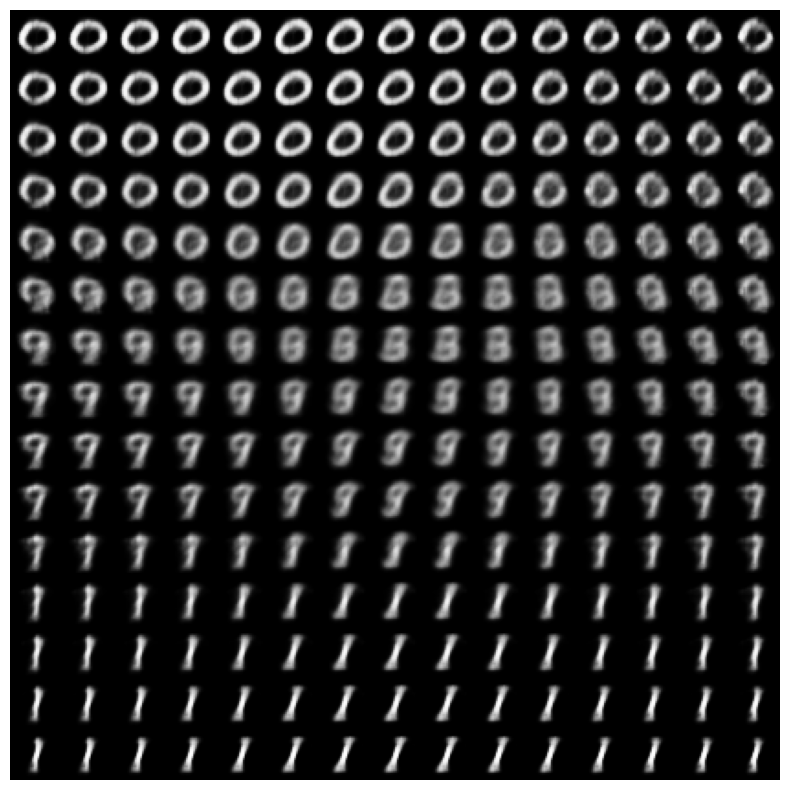


--- Latent Space Sampling (Beta=5) ---


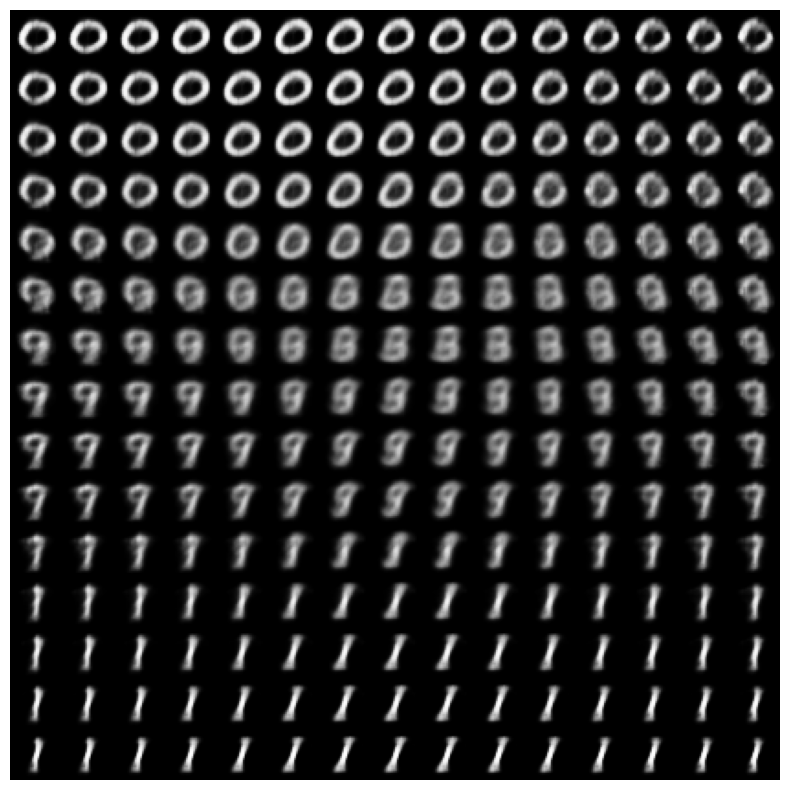


--- Latent Space Sampling (Beta=10) ---


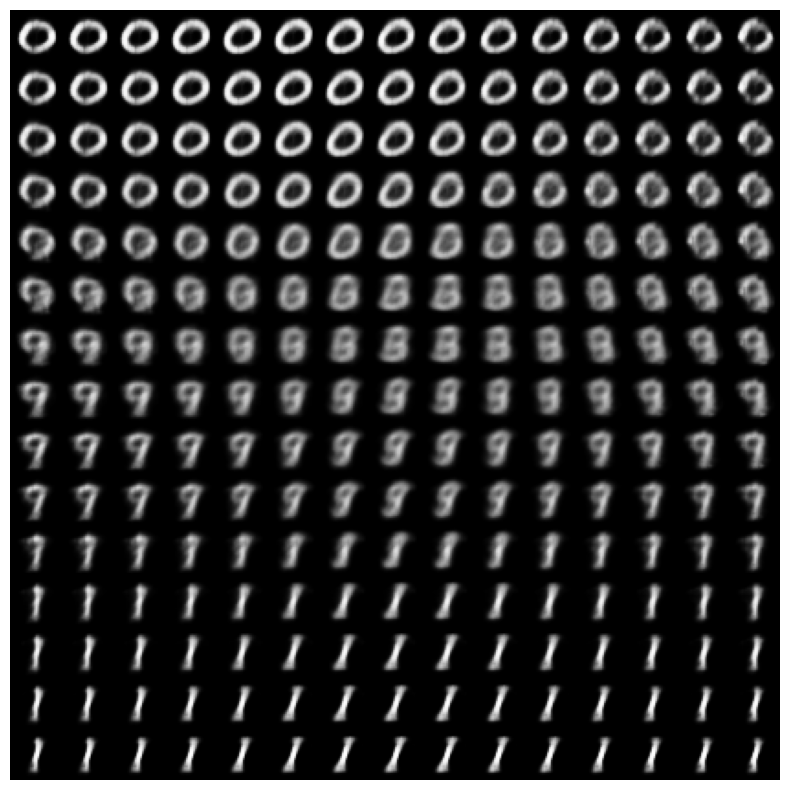

In [7]:
import matplotlib.pyplot as plt

def plot_latent_space(vae_model, n=15, digit_size=28):
    figure = np.zeros((digit_size * n, digit_size * n))

    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae_model.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap="Greys_r")
    plt.axis("off")
    plt.show()

for b in [1, 5, 10]:
    print(f"\n--- Latent Space Sampling (Beta={b}) ---")
    plot_latent_space(results_models[b])


--- Latent Interpolation (Beta=1) ---


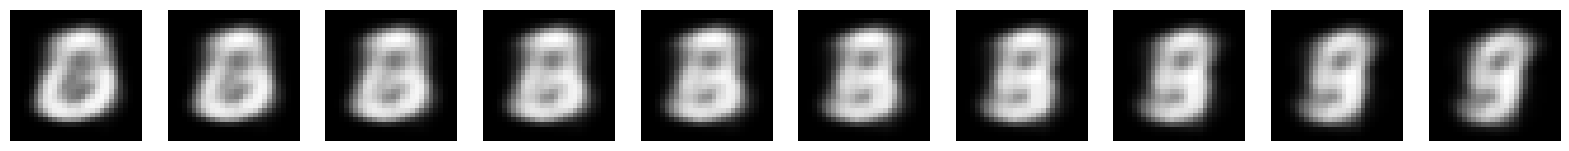


--- Latent Interpolation (Beta=5) ---


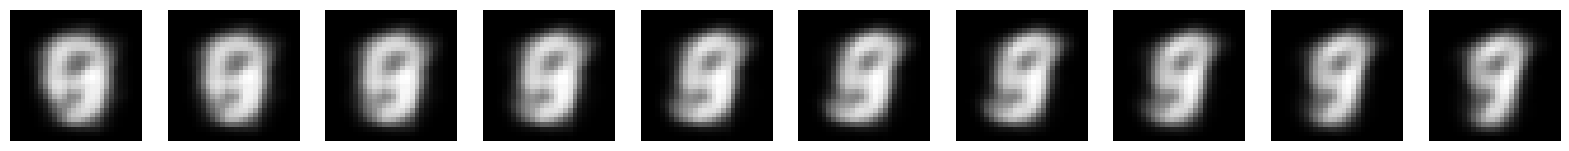


--- Latent Interpolation (Beta=10) ---


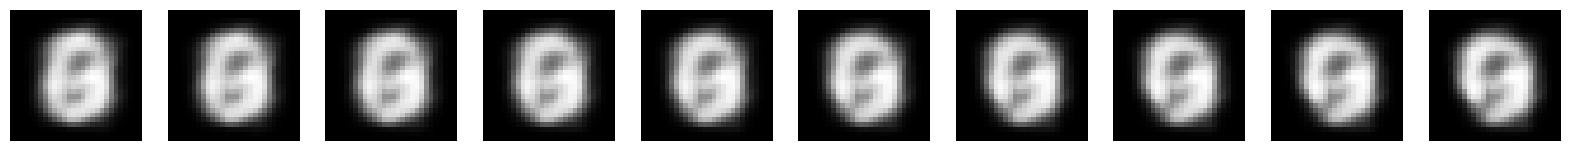

In [8]:
def plot_interpolation(vae_model, steps=10):
    # 1. Randomly sample two latent vectors
    start_vec = np.random.normal(size=(1, latent_dim))
    end_vec = np.random.normal(size=(1, latent_dim))

    # 2. Linearly interpolate between the two vectors
    lin_spaced = np.linspace(0, 1, steps)
    interpolated_vecs = np.array([(1 - alpha) * start_vec + alpha * end_vec for alpha in lin_spaced])
    interpolated_vecs = interpolated_vecs.reshape(steps, latent_dim)

    # 3. Decode the vectors
    reconstructions = vae_model.decoder.predict(interpolated_vecs, verbose=0)

    # 4. Visualize the interpolation sequence
    plt.figure(figsize=(20, 4))
    for i in range(steps):
        ax = plt.subplot(1, steps, i + 1)
        plt.imshow(reconstructions[i].reshape(28, 28), cmap="Greys_r")
        plt.axis("off")
    plt.show()

for b in [1, 5, 10]:
    print(f"\n--- Latent Interpolation (Beta={b}) ---")
    plot_interpolation(results_models[b])

## GAN Data Preparation

### Subtask:
Load and normalize the MNIST dataset for GAN training.


**Reasoning**:
I will load the MNIST dataset, normalize the pixel values to the range [-1, 1], reshape the images, and create a shuffled tf.data.Dataset with batches for efficient GAN training.



In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# 1 & 2. Load MNIST training data (labels are not needed for GANs)
(x_train, _), (_, _) = mnist.load_data()

# 3. Scale pixel values to [-1, 1] range
# (value - 127.5) / 127.5 converts 0 to -1 and 255 to 1
x_train = (x_train.astype('float32') - 127.5) / 127.5

# 4. Reshape to include channel dimension (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)

# 5. Create tf.data.Dataset for efficient iteration
BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print(f'Processed dataset shape: {x_train.shape}')
print(f'Pixel range: [{x_train.min()}, {x_train.max()}]')
print(f'Number of batches: {len(train_dataset)}')

Processed dataset shape: (60000, 28, 28, 1)
Pixel range: [-1.0, 1.0]
Number of batches: 235


## Generator and Discriminator Architectures

### Subtask:
Implement the Generator and Discriminator networks for the generative model using the Keras functional or sequential API.


**Reasoning**:
I will define the Generator and Discriminator architectures using the Keras Sequential API as per the instructions, including the latent vector input, upscaling layers for the Generator, and downsampling layers for the Discriminator.



In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# 1. Define the Generator model
latent_dim = 100

generator = Sequential([
    # Project latent noise vector
    layers.Dense(7 * 7 * 256, input_shape=(latent_dim,)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Reshape((7, 7, 256)),

    # Upscale to 14x14
    layers.Conv2DTranspose(128, kernel_size=5, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),

    # Upscale to 28x28
    layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),

    # Final output layer to match normalized range [-1, 1]
    layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding='same', activation='tanh')
], name='generator')

# 2. Define the Discriminator model
discriminator = Sequential([
    # Downsample to 14x14
    layers.Conv2D(64, kernel_size=5, strides=2, padding='same', input_shape=(28, 28, 1)),
    layers.LeakyReLU(alpha=0.2),
    layers.Dropout(0.3),

    # Downsample to 7x7
    layers.Conv2D(128, kernel_size=5, strides=2, padding='same'),
    layers.LeakyReLU(alpha=0.2),
    layers.Dropout(0.3),

    # Flatten and output single probability score
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
], name='discriminator')

# 3. Display summaries
print('--- Generator Summary ---')
generator.summary()
print('\n--- Discriminator Summary ---')
discriminator.summary()

--- Generator Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 7, 7, 128)      │       819,328 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 14, 14, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,343,681 (8.94 MB)

...

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous cell execution produced warnings regarding deprecated arguments and recommended practices for Keras models. I will refactor the architectures to use Input objects as the first layer, replace 'alpha' with 'negative_slope' in LeakyReLU, and use a standard shape for the initial Dense layer in the Generator to ensure cleaner execution.



In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# 1. Define the Generator model
latent_dim = 100

generator = Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(7 * 7 * 256),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Reshape((7, 7, 256)),

    # Upscale to 7x7
    layers.Conv2DTranspose(128, kernel_size=5, strides=1, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),

    # Upscale to 14x14
    layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),

    # Upscale to 28x28
    layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding='same', activation='tanh')
], name='generator')

# 2. Define the Discriminator model
discriminator = Sequential([
    layers.Input(shape=(28, 28, 1)),
    # Downsample to 14x14
    layers.Conv2D(64, kernel_size=5, strides=2, padding='same'),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Dropout(0.3),

    # Downsample to 7x7
    layers.Conv2D(128, kernel_size=5, strides=2, padding='same'),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Dropout(0.3),

    # Flatten and output single probability score
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
], name='discriminator')

# 3. Display summaries
print('--- Generator Summary ---')
generator.summary()
print('\n--- Discriminator Summary ---')
discriminator.summary()

--- Generator Summary ---


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 7, 7, 128)      │       819,328 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 14, 14, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,343,681 (8.94 MB)

 Trainable params: 2,318,209 (8.84 MB)

...

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

# **Part 4: Generative Adversarial Networks (GANs)**


---



## GAN Data Preparation

Load and normalize a subset of the MNIST dataset to accelerate GAN training.


In [13]:
import tensorflow as tf
import numpy as np

# 1. Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# 2. Select subset of 10,000 images
x_subset = x_train[:10000]

# 3. Normalize to [-1, 1] range
x_subset = (x_subset.astype('float32') - 127.5) / 127.5

# 4. Reshape to include channel dimension
x_subset = np.expand_dims(x_subset, axis=-1)

# 5. Create tf.data.Dataset
BUFFER_SIZE = 10000
BATCH_SIZE = 128
gan_dataset = tf.data.Dataset.from_tensor_slices(x_subset).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# 6. Verification
print(f'Subset shape: {x_subset.shape}')
print(f'Pixel range: [{x_subset.min()}, {x_subset.max()}]')
print(f'Dataset batches: {len(gan_dataset)}')

Subset shape: (10000, 28, 28, 1)
Pixel range: [-1.0, 1.0]
Dataset batches: 79


## Generator and Discriminator Architectures

Define the Generator and Discriminator networks using the Keras Sequential API, optimized for rapid convergence on the MNIST subset.


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# 1. Define the Generator model
latent_dim = 100
generator = Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(7 * 7 * 128),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Reshape((7, 7, 128)),

    # Upscale to 14x14
    layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),

    # Upscale to 28x28
    layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding='same', activation='tanh')
], name='generator')

# 2. Define the Discriminator model
discriminator = Sequential([
    layers.Input(shape=(28, 28, 1)),
    # Downsample to 14x14
    layers.Conv2D(64, kernel_size=5, strides=2, padding='same'),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Dropout(0.3),

    # Downsample to 7x7
    layers.Conv2D(128, kernel_size=5, strides=2, padding='same'),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Dropout(0.3),

    # Output layer
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
], name='discriminator')

# 3. Display summaries
print('--- Generator Summary ---')
generator.summary()
print('\n--- Discriminator Summary ---')
discriminator.summary()

--- Generator Summary ---


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 14, 14, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865,281 (3.30 MB)

 Trainable params: 852,609 (3.25 MB)

...

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

## GAN Training

Implement a custom training loop using tf.GradientTape and train the GAN for 15 epochs on the MNIST subset.


In [16]:
import tensorflow as tf
import time

# 1. Define Loss Function
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# 2. Define Optimizers
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# 3. Implement training step with @tf.function
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

# 4 & 5. Training Loop for 15 Epochs
EPOCHS = 15
print('Starting rapid training...')
for epoch in range(EPOCHS):
    start = time.time()
    epoch_gen_loss = []
    epoch_disc_loss = []

    for image_batch in gan_dataset:
        gen_loss, disc_loss = train_step(image_batch)
        epoch_gen_loss.append(gen_loss)
        epoch_disc_loss.append(disc_loss)

    print(f'Epoch {epoch+1} completed in {time.time()-start:.2f} sec | Gen Loss: {tf.reduce_mean(epoch_gen_loss):.4f} | Disc Loss: {tf.reduce_mean(epoch_disc_loss):.4f}')

print('Training finished.')

Starting rapid training...
Epoch 1 completed in 57.24 sec | Gen Loss: 1.0896 | Disc Loss: 1.1219
Epoch 2 completed in 52.42 sec | Gen Loss: 1.0405 | Disc Loss: 1.1869
Epoch 3 completed in 81.90 sec | Gen Loss: 1.1059 | Disc Loss: 1.1077
Epoch 4 completed in 51.94 sec | Gen Loss: 1.0482 | Disc Loss: 1.1670
Epoch 5 completed in 52.16 sec | Gen Loss: 1.0899 | Disc Loss: 1.1268
Epoch 6 completed in 52.06 sec | Gen Loss: 1.0562 | Disc Loss: 1.1836
Epoch 7 completed in 51.96 sec | Gen Loss: 1.0350 | Disc Loss: 1.1851
Epoch 8 completed in 63.29 sec | Gen Loss: 1.0468 | Disc Loss: 1.1122
Epoch 9 completed in 63.16 sec | Gen Loss: 1.0318 | Disc Loss: 1.1481
Epoch 10 completed in 53.40 sec | Gen Loss: 1.0114 | Disc Loss: 1.1595
Epoch 11 completed in 55.18 sec | Gen Loss: 1.0330 | Disc Loss: 1.1736
Epoch 12 completed in 52.39 sec | Gen Loss: 1.0852 | Disc Loss: 1.0937
Epoch 13 completed in 52.15 sec | Gen Loss: 0.9773 | Disc Loss: 1.2206
Epoch 14 completed in 81.91 sec | Gen Loss: 0.9947 | Disc L

## Progressive Visualization

Generate and display digit samples from the generator to visually demonstrate the learning progression after the rapid training phase.


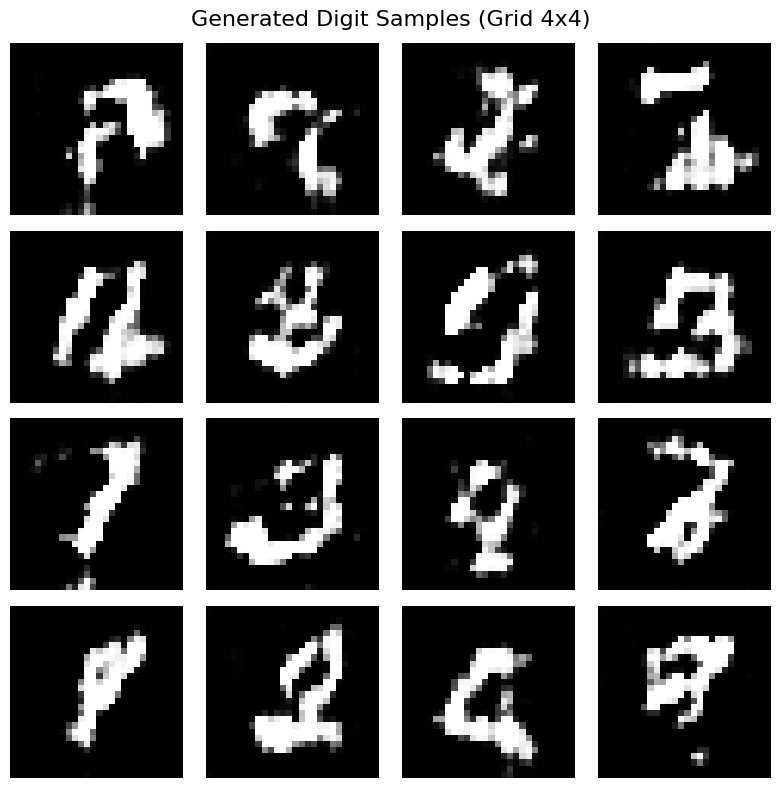

In [17]:
import matplotlib.pyplot as plt

def display_generated_samples(generator_model, latent_dimension, grid_size=4):
    # 1. Generate random noise vectors
    num_examples = grid_size * grid_size
    noise = tf.random.normal([num_examples, latent_dimension])

    # 2. Generate images from noise (inference mode)
    generated_images = generator_model(noise, training=False)

    # 3. Rescale from [-1, 1] to [0, 1] for visualization
    generated_images = (generated_images + 1.0) / 2.0

    # 4. Plotting
    plt.figure(figsize=(grid_size * 2, grid_size * 2))
    for i in range(num_examples):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(generated_images[i, :, :, 0], cmap='gray')
        plt.axis('off')

    plt.suptitle(f'Generated Digit Samples (Grid {grid_size}x{grid_size})', fontsize=16)
    plt.tight_layout()
    plt.show()

# 5. Display the final plot using the global latent_dim and trained generator
display_generated_samples(generator, latent_dim)

### Theoretical Explanation of Mode Collapse

**Mode collapse** is a common failure mode in Generative Adversarial Network (GAN) training where the Generator stops producing a diverse set of outputs and instead outputs a very limited variety of samples—sometimes even identical images—regardless of the variations in the input latent noise vector.

#### Mechanism of Mode Collapse
In a healthy GAN training session, the Generator strives to cover the entire distribution of the target data. However, since the Generator's objective is solely to fool the Discriminator, it may discover a specific 'mode' (a specific type of data, such as a single digit in MNIST) that the Discriminator currently finds highly convincing.

Once this 'sweet spot' is found, the Generator's optimal strategy (in the short term) is to produce only that specific output to maximize its reward. If the Discriminator then learns to reject that specific mode, the Generator may 'hop' to a different single mode rather than learning to represent all modes simultaneously. This results in a lack of diversity in the generated samples.

#### Theoretical Underpinnings
Theoretical reasons for mode collapse include:
- **Objective Function Biases**: The standard GAN loss function rewards the Generator for placing mass on *any* point that the Discriminator considers real, rather than penalizing it for *missing* parts of the data distribution. This is often described as the difference between minimizing the Jensen-Shannon divergence versus other metrics that might enforce better coverage.
- **Gradient Instability**: In the adversarial game, the gradients provided by the Discriminator might point toward a single point in the data space, causing the Generator's parameters to converge to a state where it maps all latent noise to that single point.

#### Lack of Formal Convergence Guarantees
GAN optimization is a non-convex, non-concave min-max game. Unlike standard deep learning tasks that minimize a single objective function, GANs seek a **Nash Equilibrium**. Theoretically, there is no formal guarantee that the stochastic gradient descent (SGD) process will reach this equilibrium. The complex landscape of the adversarial game means that the training can easily fall into limit cycles, oscillate indefinitely, or collapse into a single mode with no mathematical certainty of recovery or global convergence.

# **Part 5: Diffusion Models**


---



## Diffusion Data Preprocessing

Prepare the MNIST dataset for the Denoising Diffusion Probabilistic Model (DDPM) by normalizing pixel values and subsetting the data.


In [1]:
import tensorflow as tf
import numpy as np

# 1. Load MNIST training dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# 2. Select a subset of 10,000 images for efficiency
x_subset = x_train[:10000]

# 3. Normalize pixel values to the range [-1, 1]
# (pixel - 127.5) / 127.5 scales 0 to -1 and 255 to 1
x_subset = (x_subset.astype('float32') - 127.5) / 127.5

# 4. Reshape to include channel dimension (10000, 28, 28, 1)
x_subset = np.expand_dims(x_subset, axis=-1)

# 5. Create a shuffled and batched tf.data.Dataset
BATCH_SIZE = 64
BUFFER_SIZE = 10000
diffusion_dataset = tf.data.Dataset.from_tensor_slices(x_subset).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# 6. Verify final shape and value range
print(f'Processed dataset shape: {x_subset.shape}')
print(f'Pixel value range: [{x_subset.min()}, {x_subset.max()}]')
print(f'Number of batches: {len(diffusion_dataset)}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Processed dataset shape: (10000, 28, 28, 1)
Pixel value range: [-1.0, 1.0]
Number of batches: 157


## DDPM Implementation

Implement the core components of a simple DDPM, including the forward diffusion process and a U-Net architecture for denoising.


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

# 1. Forward Diffusion Schedule (Linear)
timesteps = 200
betas = np.linspace(1e-4, 0.02, timesteps).astype('float32')
alphas = 1.0 - betas
alphas_bar = np.cumprod(alphas)

def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = tf.random.normal(shape=tf.shape(x_start))

    sqrt_alphas_bar_t = tf.reshape(tf.gather(tf.sqrt(alphas_bar), t), (-1, 1, 1, 1))
    sqrt_one_minus_alphas_bar_t = tf.reshape(tf.gather(tf.sqrt(1.0 - alphas_bar), t), (-1, 1, 1, 1))

    return sqrt_alphas_bar_t * x_start + sqrt_one_minus_alphas_bar_t * noise

# 2 & 3. Simplified U-Net with Time Embeddings
def get_timestep_embedding(timesteps, embedding_dim=32):
    half_dim = embedding_dim // 2
    emb = np.log(10000) / (half_dim - 1)
    emb = np.exp(np.arange(half_dim) * -emb)
    emb = timesteps[:, None] * emb[None, :]
    emb = np.concatenate([np.sin(emb), np.cos(emb)], axis=-1)
    return tf.cast(emb, tf.float32)

def build_unet(img_size=28, embedding_dim=32):
    img_input = layers.Input(shape=(img_size, img_size, 1), name='image_input')
    time_input = layers.Input(shape=(embedding_dim,), name='time_input')

    temb = layers.Dense(64, activation='relu')(time_input)
    temb = layers.Dense(64)(temb)
    temb = layers.Reshape((1, 1, 64))(temb)

    c1 = layers.Conv2D(32, 3, padding='same', activation='relu')(img_input)
    p1 = layers.MaxPooling2D(2)(c1)

    b = layers.Conv2D(64, 3, padding='same', activation='relu')(p1)
    b = b + temb

    u1 = layers.UpSampling2D(2)(b)
    u1 = layers.Concatenate()([u1, c1])
    out = layers.Conv2D(1, 3, padding='same')(u1)

    return Model([img_input, time_input], out, name='unet')

unet_model = build_unet()

# 4. Custom Model for Training (calculates MSE on noise prediction)
class DDPM(Model):
    def __init__(self, unet, **kwargs):
        super().__init__(**kwargs)
        self.unet = unet

    def train_step(self, images):
        batch_size = tf.shape(images)[0]
        t = tf.random.uniform(shape=(batch_size,), minval=0, maxval=timesteps, dtype=tf.int32)
        noise = tf.random.normal(shape=tf.shape(images))

        x_noisy = q_sample(images, t, noise)
        t_emb = get_timestep_embedding(t.numpy(), embedding_dim=32)

        with tf.GradientTape() as tape:
            predicted_noise = self.unet([x_noisy, t_emb], training=True)
            loss = tf.reduce_mean(tf.square(noise - predicted_noise))

        grads = tape.gradient(loss, self.unet.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.unet.trainable_variables))
        return {'loss': loss}

# 5. Verification
print('--- U-Net Summary ---')
unet_model.summary()

sample_img = x_subset[0:1]
t_test = tf.constant([100])
noisy_sample = q_sample(sample_img, t_test)
print(f'\nForward noise test successful. Noisy sample shape: {noisy_sample.shape}')

--- U-Net Summary ---


Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_input          │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      2,112 │ time_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 14, 14,    │          0 │ conv2d_3[0][0],   │
│                     │ 64)               │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 28, 28,    │          0 │ add_1[0][0]       │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28, 28,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28, 1) │        865 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,953 (101.38 KB)

 Trainable params: 25,953 (101.38 KB)

 Non-trainable params: 0 (0.00 B)


Forward noise test successful. Noisy sample shape: (1, 28, 28, 1)


## DDPM Model and Training

Refactor the DDPM class and embedding logic to use pure TensorFlow operations for graph compatibility and train two model variants.


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

# 1. TensorFlow-native Sinusoidal Timestep Embedding
def get_timestep_embedding_tf(timesteps, embedding_dim=32):
    half_dim = embedding_dim // 2
    emb = tf.math.log(10000.0) / (tf.cast(half_dim, tf.float32) - 1.0)
    emb = tf.exp(tf.range(half_dim, dtype=tf.float32) * -emb)
    emb = tf.cast(timesteps[:, None], tf.float32) * emb[None, :]
    emb = tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)
    return emb

# 2. Rebuild U-Net Architecture
def build_unet_v2(img_size=28, embedding_dim=32):
    img_input = layers.Input(shape=(img_size, img_size, 1), name='image_input')
    time_input = layers.Input(shape=(embedding_dim,), name='time_input')

    temb = layers.Dense(64, activation='relu')(time_input)
    temb = layers.Dense(64)(temb)
    temb = layers.Reshape((1, 1, 64))(temb)

    c1 = layers.Conv2D(32, 3, padding='same', activation='relu')(img_input)
    p1 = layers.MaxPooling2D(2)(c1)
    b = layers.Conv2D(64, 3, padding='same', activation='relu')(p1)
    b = layers.Add()([b, temb])

    u1 = layers.UpSampling2D(2)(b)
    u1 = layers.Concatenate()([u1, c1])
    out = layers.Conv2D(1, 3, padding='same')(u1)
    return Model([img_input, time_input], out)

# 3. Redefine DDPM Class with Pure TF Operations
class DDPM_v2(Model):
    def __init__(self, unet, alphas_bar, timesteps, **kwargs):
        super().__init__(**kwargs)
        self.unet = unet
        self.alphas_bar = tf.cast(alphas_bar, tf.float32)
        self.num_timesteps = timesteps

    def train_step(self, images):
        batch_size = tf.shape(images)[0]
        t = tf.random.uniform(shape=(batch_size,), minval=0, maxval=self.num_timesteps, dtype=tf.int32)
        noise = tf.random.normal(shape=tf.shape(images))

        sqrt_alphas_bar_t = tf.reshape(tf.gather(tf.sqrt(self.alphas_bar), t), (-1, 1, 1, 1))
        sqrt_one_minus_alphas_bar_t = tf.reshape(tf.gather(tf.sqrt(1.0 - self.alphas_bar), t), (-1, 1, 1, 1))
        x_noisy = sqrt_alphas_bar_t * images + sqrt_one_minus_alphas_bar_t * noise

        t_emb = get_timestep_embedding_tf(t, embedding_dim=32)

        with tf.GradientTape() as tape:
            predicted_noise = self.unet([x_noisy, t_emb], training=True)
            loss = tf.reduce_mean(tf.square(noise - predicted_noise))

        grads = tape.gradient(loss, self.unet.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.unet.trainable_variables))
        return {'loss': loss}

# 4 & 5. Initialize and Train Variants
print('Training Linear Schedule Variant...')
linear_unet_v2 = build_unet_v2()
# Using linear_betas from previous cell state
linear_alphas_bar = np.cumprod(1.0 - linear_betas)
ddpm_linear = DDPM_v2(linear_unet_v2, linear_alphas_bar, timesteps=200)
ddpm_linear.compile(optimizer=tf.keras.optimizers.Adam(1e-4))
ddpm_linear.fit(diffusion_dataset, epochs=10, verbose=1)

print('\nTraining Cosine Schedule Variant...')
cosine_unet_v2 = build_unet_v2()
# get_cosine_betas was defined in previous cell
cosine_betas_val = get_cosine_betas(200)
cosine_alphas_bar = np.cumprod(1.0 - cosine_betas_val)
ddpm_cosine = DDPM_v2(cosine_unet_v2, cosine_alphas_bar, timesteps=200)
ddpm_cosine.compile(optimizer=tf.keras.optimizers.Adam(1e-4))
ddpm_cosine.fit(diffusion_dataset, epochs=10, verbose=1)

print('\nRefactoring and training complete.')

Training Linear Schedule Variant...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.8364
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5575
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3875
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3007
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2714
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2563
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2484
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2404
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2403
Epoch 10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2387

Training Cosine Schedule Variant...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.8705
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5644
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3816
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step -